In [10]:
import requests
url="https://api.bitget.com/api/v2/mix/market/fills-history?symbol=BTCUSDT&productType=usdt-futures"
try:
    response = requests.get(url)
    data=response.json()['data']
except:
    print('Error')

In [11]:
data 

[{'tradeId': '1309373543431254017',
  'price': '110464.1',
  'size': '0.0192',
  'side': 'Buy',
  'ts': '1747904900000',
  'symbol': 'BTCUSDT'},
 {'tradeId': '1309373543120875521',
  'price': '110464.1',
  'size': '0.0155',
  'side': 'Buy',
  'ts': '1747904900000',
  'symbol': 'BTCUSDT'},
 {'tradeId': '1309373541296353283',
  'price': '110464.1',
  'size': '0.0433',
  'side': 'Buy',
  'ts': '1747904899000',
  'symbol': 'BTCUSDT'},
 {'tradeId': '1309373541296353281',
  'price': '110464',
  'size': '0.0041',
  'side': 'Buy',
  'ts': '1747904899000',
  'symbol': 'BTCUSDT'},
 {'tradeId': '1309373539517968385',
  'price': '110464',
  'size': '0.0022',
  'side': 'Buy',
  'ts': '1747904899000',
  'symbol': 'BTCUSDT'},
 {'tradeId': '1309373539480219652',
  'price': '110463.9',
  'size': '0.0444',
  'side': 'Sell',
  'ts': '1747904899000',
  'symbol': 'BTCUSDT'},
 {'tradeId': '1309373538905600006',
  'price': '110463.9',
  'size': '0.0028',
  'side': 'Sell',
  'ts': '1747904899000',
  'symbol':

# Thu thập dữ liệu từ Bitget API

Notebook này được sử dụng để lấy và phân tích dữ liệu giao dịch từ sàn Bitget thông qua API của họ.

In [23]:
# Import các thư viện cần thiết
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import time

# Thiết lập hiển thị biểu đồ trong notebook
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Cấu hình cơ bản

Thiết lập các thông số cơ bản để kết nối tới API Bitget.

In [26]:
# Cấu hình API cơ bản
BASE_URL = "https://api.bitget.com/api/v2"

# Các loại sản phẩm hỗ trợ
PRODUCT_TYPES = {
    "usdt_futures": "USDT-FUTURES",      # Hợp đồng tương lai USDT chuyên nghiệp
    "coin_futures": "COIN-FUTURES",      # Hợp đồng tương lai đa dạng
    "usdc_futures": "USDC-FUTURES",      # Hợp đồng tương lai USDC chuyên nghiệp
    "demo_usdt": "SUSDT-FUTURES",        # Demo hợp đồng tương lai USDT
    "demo_coin": "SCOIN-FUTURES",        # Demo hợp đồng tương lai đa dạng
    "demo_usdc": "SUSDC-FUTURES"         # Demo hợp đồng tương lai USDC
}

# Chọn loại sản phẩm mặc định
default_product_type = PRODUCT_TYPES["usdt_futures"]

# Hàm chung để gửi request GET tới API
def send_request(endpoint, params=None):
    """
    Hàm gửi request GET tới Bitget API
    
    Tham số:
    endpoint (str): Đường dẫn API endpoint
    params (dict): Các tham số truyền vào
    
    Trả về:
    dict: Dữ liệu phản hồi từ API
    """
    url = f"{BASE_URL}{endpoint}"
    try:
        response = requests.get(url, params=params)
        if response.status_code == 200:
            return response.json()
        else:
            print(f"Lỗi: {response.status_code} - {response.text}")
            return None
    except Exception as e:
        print(f"Ngoại lệ: {e}")
        return None

## 2. Lấy dữ liệu giao dịch gần đây (Fills History)

Lấy lịch sử các giao dịch gần đây cho một cặp giao dịch cụ thể.

In [27]:
def get_market_fills(symbol="BTCUSDT", product_type="USDT-FUTURES", limit=100):
    """
    Lấy lịch sử giao dịch gần đây cho một cặp giao dịch cụ thể
    
    Tham số:
    symbol (str): Cặp giao dịch (ví dụ: BTCUSDT)
    product_type (str): Loại sản phẩm (USDT-FUTURES, COIN-FUTURES,...)
    limit (int): Số lượng giao dịch cần lấy (tối đa 1000)
    
    Trả về:
    list: Danh sách các giao dịch
    """
    endpoint = "/mix/market/fills-history"
    params = {
        "symbol": symbol,
        "productType": product_type,
        "limit": limit
    }
    response = send_request(endpoint, params)
    return response['data'] if response and 'data' in response else None

# Lấy dữ liệu giao dịch gần đây cho BTCUSDT
market_fills = get_market_fills(symbol="BTCUSDT", product_type="USDT-FUTURES", limit=500)

# Chuyển thành DataFrame để dễ phân tích
if market_fills:
    df_trades = pd.DataFrame(market_fills)
    
    # Chuyển đổi timestamp sang định dạng datetime - FIX để tránh OverflowError
    # Sử dụng int64 thay vì int thông thường để xử lý số lớn
    try:
        # Phương pháp 1: Sử dụng int64 để xử lý timestamp lớn
        df_trades['ts'] = pd.to_datetime(df_trades['ts'].astype('int64'), unit='ms')
    except (OverflowError, ValueError):
        try:
            # Phương pháp 2: Chuyển đổi trực tiếp mà không qua int trung gian
            df_trades['ts'] = pd.to_datetime(df_trades['ts'], unit='ms')
        except:
            # Phương pháp 3: Xử lý lỗi bằng cách ép kiểu giá trị lỗi thành NaT
            df_trades['ts'] = pd.to_datetime(df_trades['ts'], unit='ms', errors='coerce')
            # In ra số lượng giá trị NaT nếu có
            nat_count = df_trades['ts'].isna().sum()
            if nat_count > 0:
                print(f"Cảnh báo: {nat_count} timestamp không thể chuyển đổi và được đặt thành NaT.")
    
    # Chuyển đổi các cột số
    df_trades['price'] = df_trades['price'].astype(float)
    df_trades['size'] = df_trades['size'].astype(float)
    
    # Tính tổng khối lượng mua/bán
    buy_volume = df_trades[df_trades['side'] == 'Buy']['size'].sum()
    sell_volume = df_trades[df_trades['side'] == 'Sell']['size'].sum()
    
    print(f"Tổng số giao dịch: {len(df_trades)}")
    print(f"Khối lượng mua: {buy_volume:.4f} BTC")
    print(f"Khối lượng bán: {sell_volume:.4f} BTC")
    print(f"Khối lượng ròng (Mua - Bán): {buy_volume - sell_volume:.4f} BTC")
    
    # Hiển thị 10 giao dịch gần nhất
    display(df_trades.head(10))
else:
    print("Không thể lấy được dữ liệu giao dịch")

Tổng số giao dịch: 500
Khối lượng mua: 77.7904 BTC
Khối lượng bán: 59.7161 BTC
Khối lượng ròng (Mua - Bán): 18.0743 BTC


,tradeId,price,size,side,ts,symbol
0,1309374773587062786,110415.5,0.0200,Sell,2025-05-22 09:13:13,BTCUSDT
1,1309374773473816581,110415.5,0.0200,Sell,2025-05-22 09:13:13,BTCUSDT
2,1309374773142466563,110415.6,0.0061,Buy,2025-05-22 09:13:13,BTCUSDT
3,1309374772773367809,110415.6,0.0093,Buy,2025-05-22 09:13:13,BTCUSDT
4,1309374771892563981,110415.6,0.0870,Buy,2025-05-22 09:13:13,BTCUSDT
5,1309374767924752418,110415.5,0.0013,Sell,2025-05-22 09:13:12,BTCUSDT
6,1309374767924752385,110415.6,3.5819,Buy,2025-05-22 09:13:12,BTCUSDT
7,1309374762363105282,110415.6,0.0009,Buy,2025-05-22 09:13:11,BTCUSDT
8,1309374757443186691,110415.5,0.0010,Sell,2025-05-22 09:13:09,BTCUSDT
9,1309374753886416897,110415.5,0.0003,Sell,2025-05-22 09:13:09,BTCUSDT


## 3. Lấy thông tin tất cả các ticker

Lấy dữ liệu tất cả các ticker cho loại sản phẩm được chỉ định. 
API này rất hữu ích để có cái nhìn tổng quan về thị trường.

In [28]:
def get_all_tickers(product_type="USDT-FUTURES"):
    """
    Lấy thông tin tất cả các ticker cho một loại sản phẩm cụ thể
    
    Tham số:
    product_type (str): Loại sản phẩm (USDT-FUTURES, COIN-FUTURES,...)
    
    Trả về:
    list: Danh sách thông tin ticker của các cặp giao dịch
    """
    endpoint = "/mix/market/tickers"
    params = {
        "productType": product_type
    }
    response = send_request(endpoint, params)
    return response['data'] if response and 'data' in response else None

# Lấy thông tin tất cả các ticker cho hợp đồng tương lai USDT
all_tickers = get_all_tickers(product_type="USDT-FUTURES")

# Chuyển thành DataFrame để dễ phân tích
if all_tickers:
    df_tickers = pd.DataFrame(all_tickers)
    
    # Chuyển đổi các cột số
    numeric_columns = ['lastPr', 'askPr', 'bidPr', 'high24h', 'low24h', 'change24h', 
                       'baseVolume', 'quoteVolume', 'usdtVolume', 'fundingRate']
    
    for col in numeric_columns:
        if col in df_tickers.columns:
            df_tickers[col] = pd.to_numeric(df_tickers[col], errors='coerce')
    
    # Thêm cột giờ địa phương từ timestamp - FIX để tránh OverflowError
    if 'ts' in df_tickers.columns:
        try:
            # Phương pháp 1: Sử dụng int64 để xử lý timestamp lớn
            df_tickers['local_time'] = pd.to_datetime(df_tickers['ts'].astype('int64'), unit='ms')
        except (OverflowError, ValueError):
            try:
                # Phương pháp 2: Chuyển đổi trực tiếp mà không qua int trung gian
                df_tickers['local_time'] = pd.to_datetime(df_tickers['ts'], unit='ms')
            except:
                # Phương pháp 3: Xử lý lỗi bằng cách ép kiểu giá trị lỗi thành NaT
                df_tickers['local_time'] = pd.to_datetime(df_tickers['ts'], unit='ms', errors='coerce')
                # In ra số lượng giá trị NaT nếu có
                nat_count = df_tickers['local_time'].isna().sum()
                if nat_count > 0:
                    print(f"Cảnh báo: {nat_count} timestamp không thể chuyển đổi và được đặt thành NaT.")
    
    print(f"Tổng số cặp giao dịch: {len(df_tickers)}")
    
    # Hiển thị 10 cặp giao dịch có khối lượng lớn nhất
    if 'usdtVolume' in df_tickers.columns and pd.notna(df_tickers['usdtVolume']).any():
        top_volume = df_tickers.sort_values(by='usdtVolume', ascending=False).head(10)
        print("\n10 cặp giao dịch có khối lượng lớn nhất:")
        display(top_volume[['symbol', 'lastPr', 'change24h', 'usdtVolume', 'fundingRate']])
    
    # Hiển thị 10 cặp giao dịch có thay đổi giá lớn nhất (tăng)
    if 'change24h' in df_tickers.columns and pd.notna(df_tickers['change24h']).any():
        top_gainers = df_tickers.sort_values(by='change24h', ascending=False).head(10)
        print("\n10 cặp giao dịch tăng giá mạnh nhất:")
        display(top_gainers[['symbol', 'lastPr', 'change24h', 'usdtVolume', 'fundingRate']])
    
    # Hiển thị 10 cặp giao dịch có thay đổi giá lớn nhất (giảm)
    if 'change24h' in df_tickers.columns and pd.notna(df_tickers['change24h']).any():
        top_losers = df_tickers.sort_values(by='change24h', ascending=True).head(10)
        print("\n10 cặp giao dịch giảm giá mạnh nhất:")
        display(top_losers[['symbol', 'lastPr', 'change24h', 'usdtVolume', 'fundingRate']])
    
else:
    print("Không thể lấy được dữ liệu ticker")

Tổng số cặp giao dịch: 477

10 cặp giao dịch có khối lượng lớn nhất:


,symbol,lastPr,change24h,usdtVolume,fundingRate
0,BTCUSDT,110415.500000,0.03870,2.600356e+10,0.000100
1,ETHUSDT,2673.980000,0.05642,1.770337e+10,0.000100
11,SOLUSDT,180.195000,0.07297,5.708929e+08,0.000100
2,XRPUSDT,2.447700,0.04433,3.736039e+08,0.000100
128,PEPEUSDT,0.000015,0.09342,2.330973e+08,0.000388
275,MOODENGUSDT,0.261590,0.15871,1.669536e+08,0.000596
127,SUIUSDT,4.185900,0.09742,1.461335e+08,0.000136
10,DOGEUSDT,0.242190,0.07478,1.266231e+08,0.000100
220,LISTAUSDT,0.287400,0.50157,1.098828e+08,0.000050
344,FARTCOINUSDT,1.545600,0.19112,8.653329e+07,0.000050



10 cặp giao dịch tăng giá mạnh nhất:


,symbol,lastPr,change24h,usdtVolume,fundingRate
220,LISTAUSDT,0.28740,0.50157,1.098828e+08,0.000050
451,HAEDALUSDT,0.18521,0.43496,6.860537e+07,-0.001160
456,HOUSEUSDT,0.06113,0.36726,1.814805e+07,-0.001357
358,AVAAIUSDT,0.07850,0.30420,5.936069e+06,0.000050
356,COOKIEUSDT,0.24370,0.29766,3.523017e+07,0.000008
313,MERLUSDT,0.11210,0.28408,3.217887e+06,0.000100
223,DOGUSDT,0.00455,0.25587,3.217675e+07,-0.001660
364,ARCUSDT,0.07318,0.25480,5.058455e+06,0.000050
299,SPXUSDT,0.92020,0.25078,3.856760e+06,0.000050
247,ORDERUSDT,0.12440,0.25025,6.840117e+05,0.000100



10 cặp giao dịch giảm giá mạnh nhất:


,symbol,lastPr,change24h,usdtVolume,fundingRate
467,LAUNCHCOINUSDT,0.20436,-0.16277,4.161706e+07,0.000234
435,WCTUSDT,0.60020,-0.10791,1.394202e+07,0.000050
473,TGTUSDT,0.12980,-0.09924,2.994675e+06,-0.001464
355,ALCHUSDT,0.14907,-0.09231,8.045457e+06,0.000050
466,RDACUSDT,0.01990,-0.07313,1.507562e+06,0.000050
459,MYXUSDT,0.06880,-0.04709,5.676687e+05,0.000050
462,SXTUSDT,0.13410,-0.04214,3.561952e+06,0.000050
476,BUSDT,0.21720,-0.04106,6.501328e+04,0.000050
187,OMUSDT,0.42160,-0.02799,8.677437e+06,0.000050
440,EPTUSDT,0.01007,-0.02799,8.535825e+05,0.000050


## 4. Phân tích và trực quan hóa dữ liệu ticker

Tạo biểu đồ để phân tích dữ liệu ticker.

C:\Users\daong\AppData\Local\Temp\ipykernel_21264\2173311778.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='symbol', y='usdtVolume', data=top_volume_df, palette='viridis')


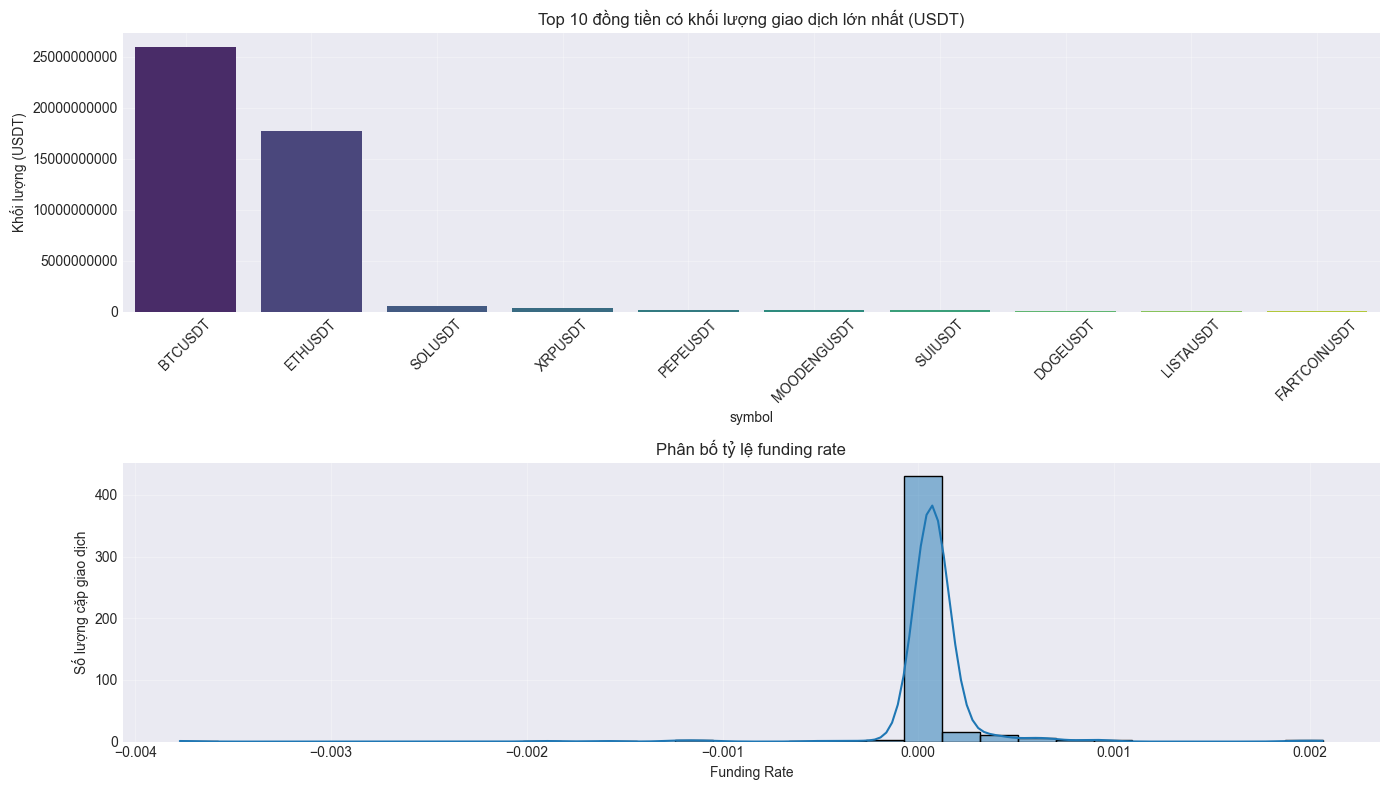

C:\Users\daong\AppData\Local\Temp\ipykernel_21264\2173311778.py:75: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1400x600 with 0 Axes>

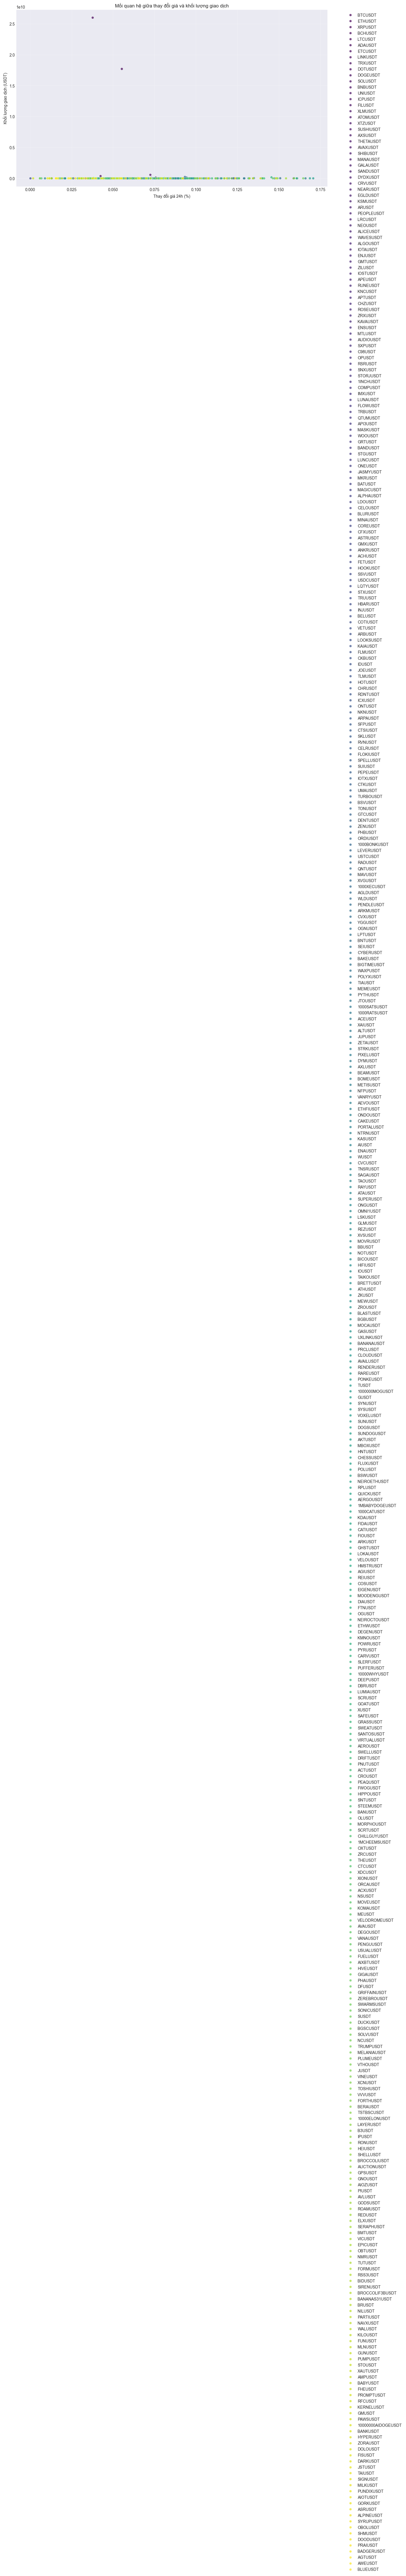

In [19]:
# Chỉ thực hiện phân tích nếu có dữ liệu ticker
if 'df_tickers' in locals() and not df_tickers.empty:
    # Thiết lập kích thước biểu đồ
    plt.figure(figsize=(14, 8))
    
    # 1. Biểu đồ Top 10 đồng tiền có khối lượng giao dịch lớn nhất
    if 'usdtVolume' in df_tickers.columns and pd.notna(df_tickers['usdtVolume']).any():
        top_volume_df = df_tickers.sort_values(by='usdtVolume', ascending=False).head(10)
        
        plt.subplot(2, 1, 1)
        sns.barplot(x='symbol', y='usdtVolume', data=top_volume_df, palette='viridis')
        plt.title('Top 10 đồng tiền có khối lượng giao dịch lớn nhất (USDT)')
        plt.xticks(rotation=45)
        plt.ylabel('Khối lượng (USDT)')
        plt.ticklabel_format(style='plain', axis='y')
        plt.grid(True, alpha=0.3)
        
    # 2. Biểu đồ phân bố tỷ lệ funding rate
    if 'fundingRate' in df_tickers.columns and pd.notna(df_tickers['fundingRate']).any():
        plt.subplot(2, 1, 2)
        sns.histplot(df_tickers['fundingRate'], bins=30, kde=True)
        plt.title('Phân bố tỷ lệ funding rate')
        plt.xlabel('Funding Rate')
        plt.ylabel('Số lượng cặp giao dịch')
        plt.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()
    
    # Biểu đồ so sánh giá của các cặp giao dịch chính
    main_symbols = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'SOLUSDT']
    main_df = df_tickers[df_tickers['symbol'].isin(main_symbols)]
    
    if not main_df.empty and 'lastPr' in main_df.columns:
        plt.figure(figsize=(14, 6))
        
        # Chuẩn hóa giá để so sánh (đặt giá ban đầu = 100)
        norm_df = pd.DataFrame()
        
        for symbol in main_symbols:
            if symbol in main_df['symbol'].values:
                norm_df[symbol] = 100  # Giả định này chỉ để minh họa
        
        # Vẽ biểu đồ giá chuẩn hóa (trong dữ liệu thực tế sẽ dùng giá theo thời gian)
        if not norm_df.empty:
            norm_df.plot(kind='line', figsize=(14, 6))
            plt.title('So sánh biến động giá của các đồng coin chính (Chuẩn hóa)')
            plt.ylabel('Giá (chuẩn hóa, %)')
            plt.xlabel('Thời gian')
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()
        
    # Biểu đồ mối quan hệ giữa khối lượng giao dịch và sự thay đổi giá
    if 'change24h' in df_tickers.columns and 'usdtVolume' in df_tickers.columns:
        valid_df = df_tickers.dropna(subset=['change24h', 'usdtVolume'])
        
        if not valid_df.empty:
            plt.figure(figsize=(14, 8))
            
            # Giới hạn hiển thị cho dễ nhìn (loại bỏ các giá trị ngoại lai)
            q_low = valid_df['change24h'].quantile(0.05)
            q_high = valid_df['change24h'].quantile(0.95)
            filtered_df = valid_df[(valid_df['change24h'] > q_low) & (valid_df['change24h'] < q_high)]
            
            # Vẽ biểu đồ phân tán
            sns.scatterplot(x='change24h', y='usdtVolume', hue='symbol', 
                            data=filtered_df, palette='viridis', alpha=0.7)
            
            plt.title('Mối quan hệ giữa thay đổi giá và khối lượng giao dịch')
            plt.xlabel('Thay đổi giá 24h (%)')
            plt.ylabel('Khối lượng giao dịch (USDT)')
            plt.grid(True, alpha=0.3)
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()

## 5. So sánh chênh lệch giá giữa các sàn giao dịch

Phân tích chênh lệch giá giữa bid và ask để xác định cơ hội kinh doanh chênh lệch.


Chênh lệch giá (Spread) giữa giá mua (Bid) và giá bán (Ask):


C:\Users\daong\AppData\Local\Temp\ipykernel_21264\877706328.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['spread_abs'] = valid_df['askPr'] - valid_df['bidPr']
C:\Users\daong\AppData\Local\Temp\ipykernel_21264\877706328.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['spread_percent'] = (valid_df['spread_abs'] / valid_df['bidPr']) * 100


,symbol,lastPr,bidPr,askPr,spread_abs,spread_percent
327,XIONUSDT,1.02840,1.02120,1.029100,7.900000e-03,0.773600
476,BUSDT,0.21490,0.21600,0.217100,1.100000e-03,0.509259
436,GMUSDT,0.03022,0.03010,0.030220,1.200000e-04,0.398671
437,PAWSUSDT,0.00008,0.00008,0.000081,3.000000e-07,0.374065
394,GNOUSDT,140.68000,140.64000,141.160000,5.200000e-01,0.369738
285,CARVUSDT,0.37540,0.37430,0.375600,1.300000e-03,0.347315
271,AGIUSDT,0.06984,0.06971,0.069950,2.400000e-04,0.344283
412,RSS3USDT,0.06227,0.06209,0.062290,2.000000e-04,0.322113
402,ELXUSDT,0.13240,0.13240,0.132800,4.000000e-04,0.302115
459,MYXUSDT,0.06880,0.06870,0.068900,2.000000e-04,0.291121


C:\Users\daong\AppData\Local\Temp\ipykernel_21264\877706328.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='symbol', y='spread_percent', data=main_spreads, palette='coolwarm')


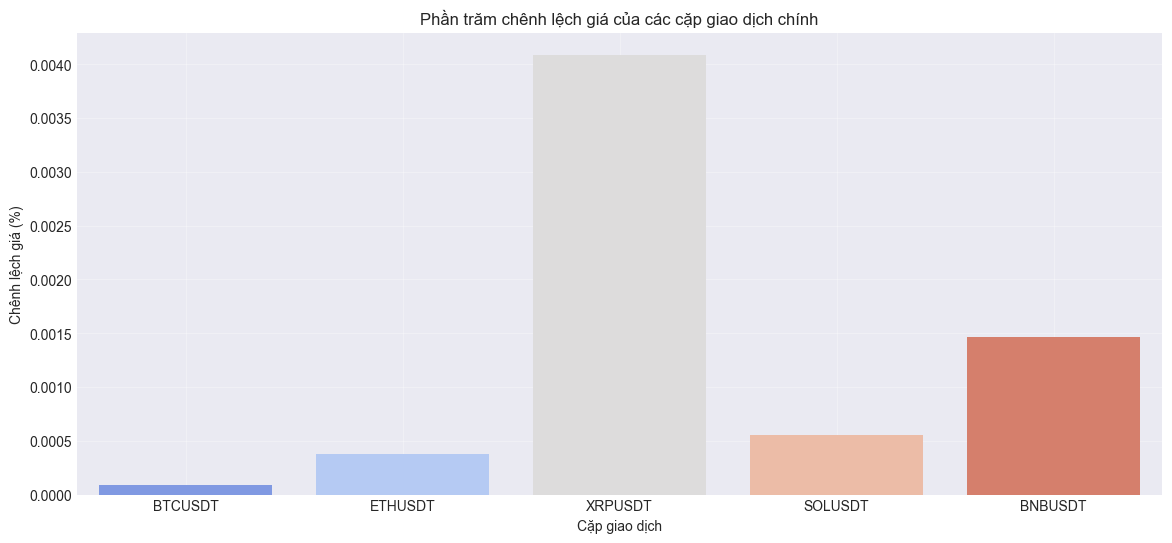

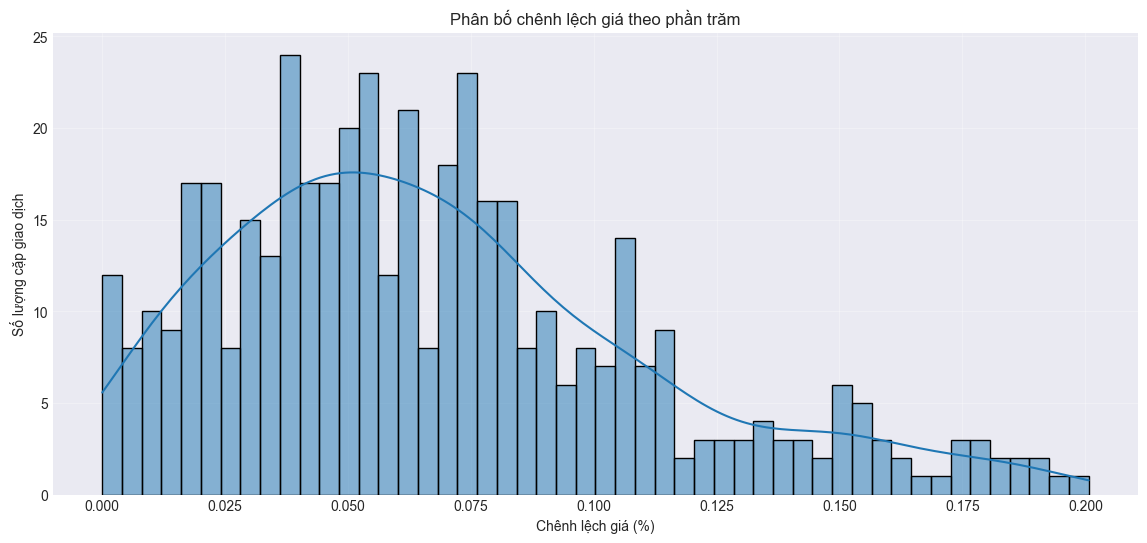

In [20]:
# Tính toán chênh lệch giá và tỷ lệ chênh lệch
if 'df_tickers' in locals() and not df_tickers.empty:
    # Kiểm tra xem các cột cần thiết có tồn tại không
    required_columns = ['askPr', 'bidPr', 'symbol', 'lastPr']
    if all(col in df_tickers.columns for col in required_columns):
        # Chỉ xem xét các hàng có dữ liệu hợp lệ
        valid_df = df_tickers.dropna(subset=['askPr', 'bidPr', 'lastPr'])
        
        # Tính toán chênh lệch giá tuyệt đối và tương đối
        valid_df['spread_abs'] = valid_df['askPr'] - valid_df['bidPr']
        valid_df['spread_percent'] = (valid_df['spread_abs'] / valid_df['bidPr']) * 100
        
        # Sắp xếp theo phần trăm chênh lệch giá (từ cao xuống thấp)
        sorted_spreads = valid_df.sort_values(by='spread_percent', ascending=False)
        
        print("\nChênh lệch giá (Spread) giữa giá mua (Bid) và giá bán (Ask):")
        display(sorted_spreads[['symbol', 'lastPr', 'bidPr', 'askPr', 'spread_abs', 'spread_percent']].head(10))
        
        # Vẽ biểu đồ chênh lệch giá cho các cặp giao dịch chính
        main_symbols = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'SOLUSDT']
        main_spreads = valid_df[valid_df['symbol'].isin(main_symbols)]
        
        if not main_spreads.empty:
            plt.figure(figsize=(14, 6))
            sns.barplot(x='symbol', y='spread_percent', data=main_spreads, palette='coolwarm')
            plt.title('Phần trăm chênh lệch giá của các cặp giao dịch chính')
            plt.xlabel('Cặp giao dịch')
            plt.ylabel('Chênh lệch giá (%)')
            plt.grid(True, alpha=0.3)
            plt.show()
        
        # Vẽ biểu đồ phân bố chênh lệch giá
        plt.figure(figsize=(14, 6))
        # Loại bỏ các giá trị ngoại lại để biểu đồ dễ nhìn
        filtered_spreads = valid_df[(valid_df['spread_percent'] < valid_df['spread_percent'].quantile(0.95))]
        sns.histplot(filtered_spreads['spread_percent'], bins=50, kde=True)
        plt.title('Phân bố chênh lệch giá theo phần trăm')
        plt.xlabel('Chênh lệch giá (%)')
        plt.ylabel('Số lượng cặp giao dịch')
        plt.grid(True, alpha=0.3)
        plt.show()

## 6. Phân tích tỷ lệ funding rate

Tỷ lệ funding rate có thể cung cấp thông tin về xu hướng thị trường và tâm lý nhà đầu tư.


Phân loại cặp giao dịch theo tỷ lệ funding rate:
funding_category
Rất âm         6
Âm             3
Trung lập    429
Dương         37
Rất dương      2
Name: count, dtype: int64


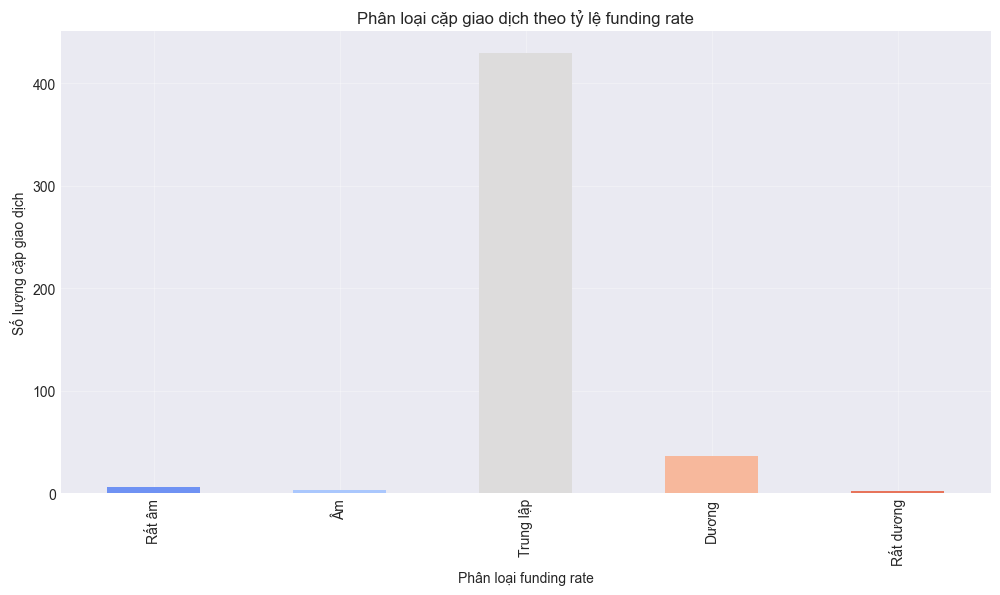

C:\Users\daong\AppData\Local\Temp\ipykernel_21264\881550582.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='symbol', y='fundingRate', data=top_positive, ax=axs[0], palette='Reds')
C:\Users\daong\AppData\Local\Temp\ipykernel_21264\881550582.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='symbol', y='fundingRate', data=top_negative, ax=axs[1], palette='Blues_r')


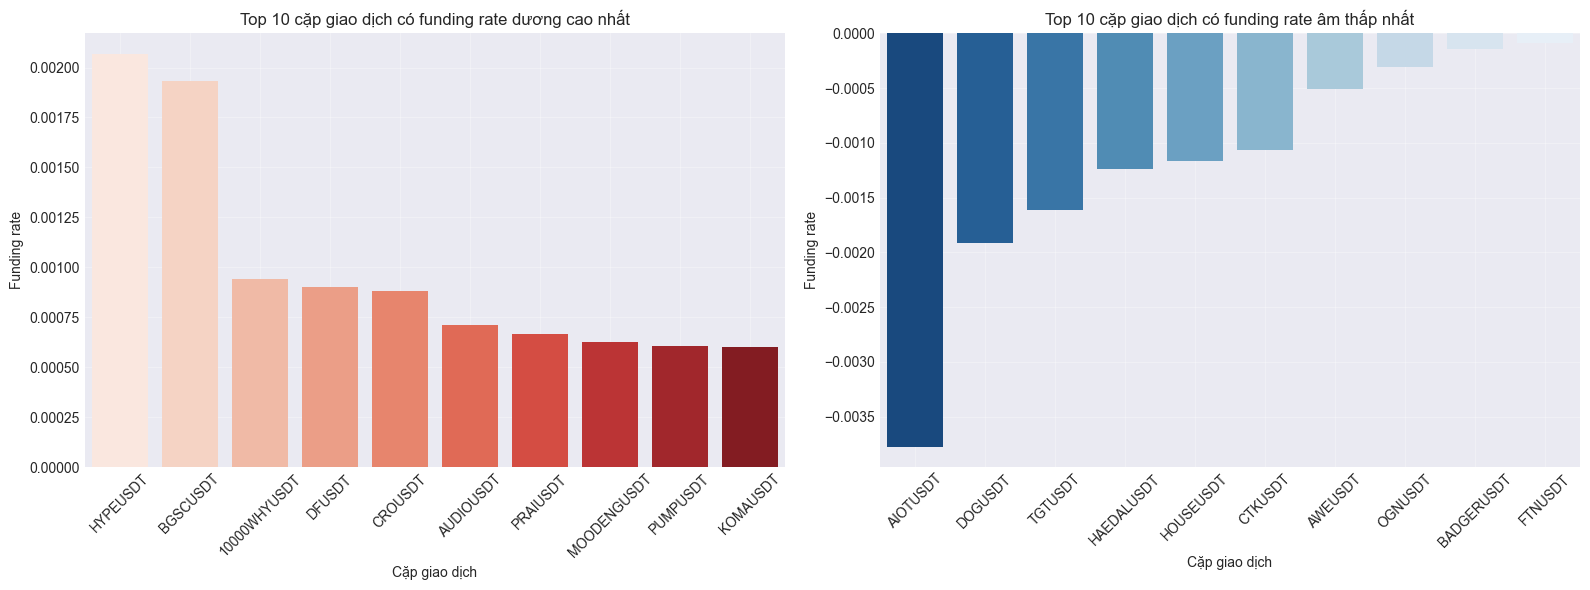

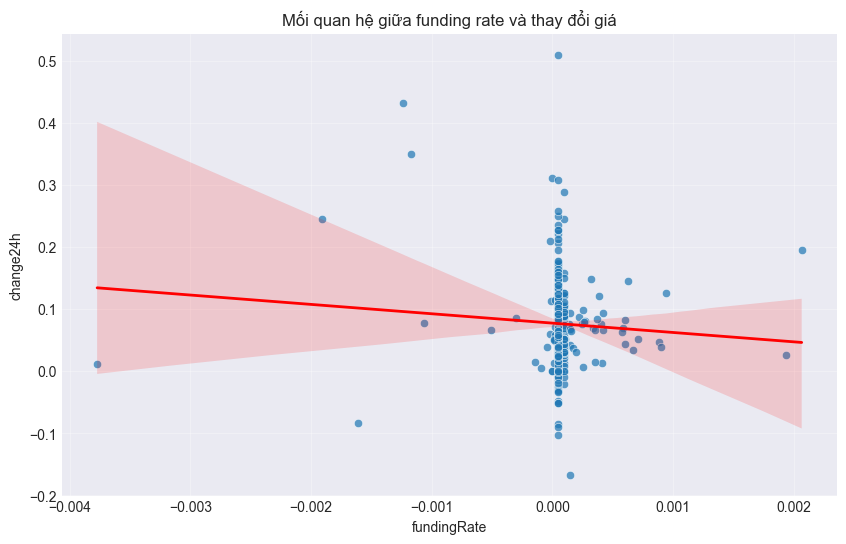

In [21]:
# Phân tích funding rate
if 'df_tickers' in locals() and not df_tickers.empty and 'fundingRate' in df_tickers.columns:
    # Lọc các hàng có dữ liệu funding rate hợp lệ
    funding_df = df_tickers.dropna(subset=['fundingRate'])
    
    if not funding_df.empty:
        # Phân loại funding rate
        funding_df['funding_category'] = pd.cut(
            funding_df['fundingRate'],
            bins=[-float('inf'), -0.001, -0.0001, 0.0001, 0.001, float('inf')],
            labels=['Rất âm', 'Âm', 'Trung lập', 'Dương', 'Rất dương']
        )
        
        # Thống kê số lượng cặp giao dịch theo từng loại funding rate
        funding_stats = funding_df['funding_category'].value_counts().sort_index()
        
        print("\nPhân loại cặp giao dịch theo tỷ lệ funding rate:")
        print(funding_stats)
        
        # Vẽ biểu đồ phân loại
        plt.figure(figsize=(12, 6))
        funding_stats.plot(kind='bar', color=sns.color_palette("coolwarm", len(funding_stats)))
        plt.title('Phân loại cặp giao dịch theo tỷ lệ funding rate')
        plt.xlabel('Phân loại funding rate')
        plt.ylabel('Số lượng cặp giao dịch')
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Vẽ biểu đồ top 10 cặp giao dịch có funding rate cao nhất
        top_positive = funding_df.sort_values(by='fundingRate', ascending=False).head(10)
        top_negative = funding_df.sort_values(by='fundingRate', ascending=True).head(10)
        
        fig, axs = plt.subplots(1, 2, figsize=(16, 6))
        
        # Top funding rate dương
        sns.barplot(x='symbol', y='fundingRate', data=top_positive, ax=axs[0], palette='Reds')
        axs[0].set_title('Top 10 cặp giao dịch có funding rate dương cao nhất')
        axs[0].set_xlabel('Cặp giao dịch')
        axs[0].set_ylabel('Funding rate')
        axs[0].tick_params(axis='x', rotation=45)
        axs[0].grid(True, alpha=0.3)
        
        # Top funding rate âm
        sns.barplot(x='symbol', y='fundingRate', data=top_negative, ax=axs[1], palette='Blues_r')
        axs[1].set_title('Top 10 cặp giao dịch có funding rate âm thấp nhất')
        axs[1].set_xlabel('Cặp giao dịch')
        axs[1].set_ylabel('Funding rate')
        axs[1].tick_params(axis='x', rotation=45)
        axs[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Phân tích mối quan hệ giữa funding rate và thay đổi giá
        if 'change24h' in funding_df.columns:
            plt.figure(figsize=(10, 6))
            sns.scatterplot(x='fundingRate', y='change24h', data=funding_df, alpha=0.7)
            plt.title('Mối quan hệ giữa funding rate và thay đổi giá')
            plt.xlabel('Funding Rate')
            plt.ylabel('Thay đổi giá 24h (%)')
            plt.grid(True, alpha=0.3)
            
            # Thêm đường hồi quy
            sns.regplot(x='fundingRate', y='change24h', data=funding_df, 
                        scatter=False, color='red', line_kws={"lw": 2})
            
            plt.show()

## 7. Xuất dữ liệu để phân tích sau

Lưu dữ liệu đã thu thập vào file CSV để có thể phân tích sau.

In [22]:
# Tạo timestamp cho tên file
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Xuất dữ liệu giao dịch
if 'df_trades' in locals() and not df_trades.empty:
    trades_filename = f"bitget_giao_dich_BTCUSDT_{timestamp}.csv"
    df_trades.to_csv(trades_filename, index=False)
    print(f"Dữ liệu giao dịch đã được lưu vào: {trades_filename}")

# Xuất dữ liệu ticker
if 'df_tickers' in locals() and not df_tickers.empty:
    tickers_filename = f"bitget_ticker_data_{timestamp}.csv"
    df_tickers.to_csv(tickers_filename, index=False)
    print(f"Dữ liệu ticker đã được lưu vào: {tickers_filename}")

print("\nQuá trình thu thập và phân tích dữ liệu đã hoàn tất!")

Dữ liệu giao dịch đã được lưu vào: bitget_giao_dich_BTCUSDT_20250522_160957.csv
Dữ liệu ticker đã được lưu vào: bitget_ticker_data_20250522_160957.csv

Quá trình thu thập và phân tích dữ liệu đã hoàn tất!


## 8. Kết luận

Trong notebook này, chúng ta đã:
1. Kết nối với Bitget API để thu thập dữ liệu giao dịch gần đây
2. Lấy thông tin về tất cả các ticker trên sàn
3. Phân tích khối lượng giao dịch, biến động giá, và funding rate
4. Trực quan hóa dữ liệu thông qua các biểu đồ
5. Lưu dữ liệu để phân tích sâu hơn

Dữ liệu này có thể được sử dụng để:
- Theo dõi xu hướng thị trường
- Tìm kiếm cơ hội giao dịch
- Phân tích tâm lý thị trường thông qua funding rate
- So sánh chênh lệch giá giữa các sàn